In [1]:
import matplotlib.pyplot as plt
import gymnasium as gym
import numpy as np
import torch
import src.metropolis_hastings as mh
import time

from src.time_varying_vine_copula import tv_vinecop, obs_transform_pend2, action_transform_pendulum, SlidingWindowDataset
from src.copula import conditional_vine_copula
from rl_code.modelnp import pendulum
from rl_code.lspi import LSPI

from src.qbvine import qb_conditional_vine

In [2]:
n_episodes, sim_len, n_eval, n_stop_modelupdate = 10, 1000, 5, 25
true_param = np.array([9.8, 2.0, 8.0, 0.5,10.0, 0.1])
true_pendulum = pendulum(true_param)
my_lspi = LSPI(true_pendulum, sim_len, None)
old_policy = my_lspi.random_policy

st = time.time()

### calculate episodic return
all_returns, disc_returns = [], []
init_state = np.random.uniform(low=-1e-10, high=1e-10, size=2)
all_s = np.empty((0, 2))
all_s2 = np.empty((0, 2))
all_a = np.empty((0,1))
episode_ends = np.zeros(n_eval, dtype = int)
end_idx = 0
for i in range(n_eval):
    eval_s, eval_a, eval_s2, eval_r = true_pendulum.simulate_episode(first_state=init_state, policy=old_policy)
    end_idx += len(eval_r)
    episode_ends[i] = end_idx-1
    print(eval_r.T)
    all_s = np.concatenate((all_s, eval_s))
    all_s2 = np.concatenate((all_s2, eval_s2))
    all_a = np.concatenate((all_a, eval_a))
    discounts = np.array(my_lspi.gamma**np.arange(len(eval_r)))
    discounted_return = discounts.T @ np.array(eval_r)
    all_returns.append(np.sum(eval_r)), disc_returns.append(discounted_return[0])
print(f"Episode 1 return: {np.mean(all_returns)}")
print(episode_ends)
print(len(all_a))

[[1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 0.]]
Episode 1 return: 9.2
[ 9 20 32 43 50]
51


In [3]:
n_episodes, sim_len, n_eval, n_stop_modelupdate = 10, 1000, 5, 25
true_param = np.array([9.8, 2.0, 8.0, 0.5,10.0, 0.1])
true_pendulum = pendulum(true_param)
my_lspi = LSPI(true_pendulum, sim_len, None)
old_policy = my_lspi.random_policy
n_acts = 0
while n_acts <30:
    eval_s, eval_a, eval_s2, eval_r = true_pendulum.simulate_episode(first_state=init_state, policy=old_policy)
    end_idx += len(eval_r)
    n_acts = len(eval_a)
print(eval_r.T)

all_s = eval_s
all_a = eval_a
all_s2 = eval_s2

[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 0.]]


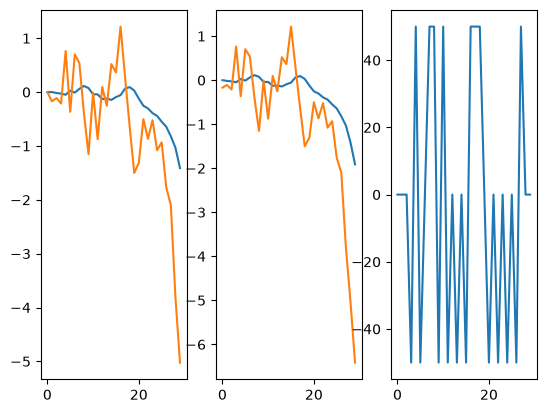

In [4]:
fig, ax = plt.subplots(1,3)
ax[0].plot(all_s)
ax[1].plot(all_s2)
ax[2].plot(all_a)


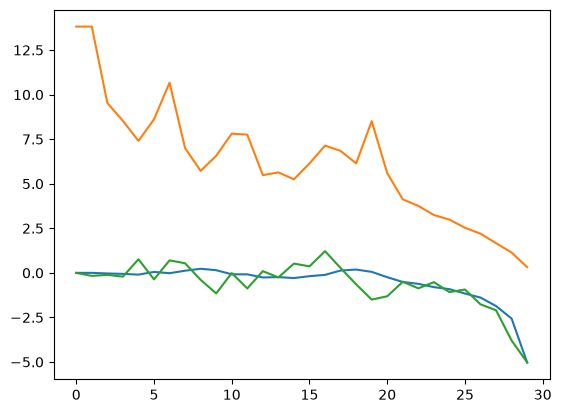

In [5]:
data = np.concatenate((all_s, all_a), axis=1)

obs_transformer = obs_transform_pend2(standardise=False)
obs_transformer.fit(torch.from_numpy(all_s))
trans_obs = obs_transformer.transform(torch.from_numpy(all_s)).numpy()

trans_data = np.concatenate((trans_obs, all_a), axis=1)

plt.plot(trans_obs)

In [6]:
print("Starting Fit")
# tv = tv_vinecop(observation_d=3, action_d=1, discrete_action=1, action_set=np.unique(all_a))
# tv.fit(trans_data, check_vines=True, episode_ends = None)
condcop = qb_conditional_vine(observation_d=3, discrete_action=1, action_set=np.unique(all_a))
condcop.fit(trans_data, check_vines=True)

print("Fit finished")


Starting Fit
[4 5 6 7] [1 2 3] [1 2 3 5 6 7 8 9]
Cauchy Locs = [np.float64(-0.07083357117589664), np.float64(6.256815183084019), np.float64(-0.329347765963903)]
Scales = [np.float64(0.1845460618882626), np.float64(1.74422782227466), np.float64(0.5413800405290107)]
-0.07083357117589664 0.1845460618882626
6.256815183084019 1.74422782227466
-0.329347765963903 0.5413800405290107
var_types = ['c', 'c', 'c', 'c', 'c', 'c', 'd']
<pyvinecopulib.core.Vinecop> Vinecop model with 7 variables
tree edge conditioned variables conditioning variables var_types       family rotation parameters  df   tau 
   1    1                  3, 2                             c, c     Gaussian        0       0.12 1.0  0.08 
   1    2                  1, 5                             c, c       Gumbel      180       3.82 1.0  0.74 
   1    3                  2, 5                             c, c      Clayton        0       1.96 1.0  0.50 
   1    4                  4, 5                             c, c          Joe 

In [ ]:
print(trans_obs[0])

tv.step_forward(np.array([trans_obs[0]]), all_a[0][0])
print(tv.last_state.shape)
print(np.array([trans_obs[0]]))

predicted_next = np.zeros_like(all_s)
predicted_up_err = np.zeros_like(all_s)
predicted_down_err = np.zeros_like(all_s)
predicted_next[0] = all_s[0]

tv.check_rbp_pdfs_real_line(x_max=30)
#tv.check_conditional_vine_pdfs()
tv.check_rbp_times_conditional_vine()
plt.show()

In [ ]:
tv.step_forward(np.array([trans_obs[0]]), all_a[0][0])


for i, act in enumerate(all_a[0:9]):
    pred, pred_std, ar, fig = tv.predict_next_state(action = act[0], covariance=0.01, chain_length=600, 
                                                    burn_in = 300, check_chain=True, check_acceptance = False)
    plt.show()
    plt.close()
    print(pred)
    predicted_next[i+1] = obs_transformer.inverse_transform(torch.from_numpy(np.expand_dims(pred, axis=0)))
    predicted_up_err[i+1] = obs_transformer.inverse_transform(torch.from_numpy(np.expand_dims(pred+pred_std, axis=0)))
    predicted_down_err[i+1] = obs_transformer.inverse_transform(torch.from_numpy(np.expand_dims(pred-pred_std, axis=0)))
    print(i, act[0], ar)

    tv.step_forward(np.array([pred]), all_a[i+1][0])

In [ ]:
print(predicted_next)
fig, ax = plt.subplots(2,2)
x = np.arange(len(predicted_next))
#Plot the 
for i in range(2):
    ax[0, i].plot(x, all_s2[:,i], label = "Observed")
    ax[0, i].plot(x, predicted_next[:,i], label = "Prediction")
    ax[0, i].fill_between(
        x,
        predicted_up_err[:, i],
        predicted_down_err[:, i],
        color = "orange",
        alpha=0.25,
        label="Prediction uncertainty"
    )
    #ax[1, i].plot(observations[:,i], predicted_next[:,i] - observations[:,i], '.')

#print(observations[-11], observations[-10], np.mean(chain, axis=0), observations[-9])
plt.savefig("C:/Users/woodg/Documents/Vine_dissertation_chaeyun/plots_rl/roll_out_discrete")
plt.close()